In [1]:
import os
import sys
sys.path.append('/host/d/Github')  ### remove this if not needed!
import numpy as np
import pandas as pd 
from tqdm import tqdm 
from pathlib import Path
import nibabel as nb
import matplotlib.pyplot as plt

import argparse
from einops import rearrange
from natsort import natsorted
from madgrad import MADGRAD

import torch
import torch.backends.cudnn as cudnn

from SAM_echo_xjtlu.utils.model_util import *
from SAM_echo_xjtlu.segment_anything.model import build_model 
from SAM_echo_xjtlu.utils.save_utils import *
from SAM_echo_xjtlu.utils.config_util import Config
from SAM_echo_xjtlu.utils.misc import NativeScalerWithGradNormCount as NativeScaler

from SAM_echo_xjtlu.train_engine import train_loop

import SAM_echo_xjtlu.functions_collection as ff
import SAM_echo_xjtlu.Data_processing as Data_processing
import SAM_echo_xjtlu.Build_lists.Build_list as Build_list
import SAM_echo_xjtlu.data_loader.random_aug as random_aug
import SAM_echo_xjtlu.data_loader.generator as generator
from torch.utils.data import Dataset, DataLoader


main_path = '/host/d/projects/FETUS_competition/' ### change to your main path


### step 1: define trial name

In [2]:
trial_name = 'trial'
output_dir = os.path.join(main_path, 'models', trial_name) # change to your output dir
ff.make_folder([output_dir])

### step 2: define parameters for this trial

In [3]:
# many important parameters, focus on ones that I comment with ###!!

def get_args_parser(img_size = 128, num_classes = 3, pretrained_model = None, original_sam = None, start_epoch = None, total_training_epochs = 1000, save_model_every = 1,  vit_type = "vit_h"):
    parser = argparse.ArgumentParser('SAM fine-tuning', add_help=True)

    # img size
    parser.add_argument('--img_size', default=img_size, type=int)  ## !!

    ## augmentation
    parser.add_argument('--augment_frequency', default= 0.8, type=float) ## !!

    ## segmentation classes
    parser.add_argument('--num_classes', type=int, default=num_classes) ## !!

    ## pretrained sam
    parser.add_argument('--resume', default = original_sam) ##!!

    # for training
    parser.add_argument('--total_training_epochs', default = total_training_epochs, type=int)
    parser.add_argument('--accum_iter', default=20, type=int, help='Accumulate gradient iterations (for increasing the effective batch size under memory constraints)') ##!!
    parser.add_argument('--print_freq', default=10, type = int) 
    parser.add_argument('--save_model_file_every_N_epoch', default=save_model_every, type = int)  ## !!
    parser.add_argument('--batch_size', default=1, type=int, help='Batch size per GPU (effective batch size is batch_size * accum_iter * # gpus')  ## !!
    parser.add_argument('--weight_decay', type=float, default=0.05, help='weight decay (default: 0.05)')
    parser.add_argument('--lr', type=float, default=1e-4, metavar='LR', help='base learning rate: absolute_lr = base_lr * total_batch_size / 256') ## !!
    parser.add_argument('--lr_update_every_N_epoch', default=100, type = int) ## !!
    parser.add_argument('--lr_decay_gamma', default=0.95)
    parser.add_argument('--warmup_epochs', type=int, default=10, metavar='N', help='epochs to warmup LR')
    parser.add_argument('--loss_weights', default = [0,1] )  #### !! weighting for loss function [BCE, Dice]

    if start_epoch == None:
        parser.add_argument('--start_epoch', default=1, type=int, metavar='N', help='start epoch')
    else:
        parser.add_argument('--start_epoch', default= start_epoch, type=int, metavar='N', help='start epoch')

    # standard
    parser.add_argument('--text_prompt', default = False)
    parser.add_argument('--box_prompt', default= False) 
    parser.add_argument('--pretrained_model', default = pretrained_model)
    
    parser.add_argument('--validation', default=False) ## !!
    parser.add_argument('--cross_frame_attention', default=False) # False

    parser.add_argument('--model_type', type=str, default='sam')
    parser.add_argument('--n_gpu', type=int, default=1, help='total gpu') 
    parser.add_argument('--use_amp', action='store_true', help='If activated, adopt mixed precision for acceleration')
    parser.add_argument("--config", help="Path to the training config file.", default="configs/config.yaml",)

    parser.add_argument('--seed', default=1234, type=int)   
    parser.add_argument('--input_type', type=str, default='2DT') #has to be 2DT
    parser.add_argument('--vit_type', type=str, default=vit_type)
    parser.add_argument('--max_timeframe', default=1, type=int) 
                        

    parser.add_argument('--turn_zero_seg_slice_into', default=10, type=int)
 
    return parser


In [4]:
pretrained_model = None#os.path.join(output_dir, 'model-1000.pth')
start_epoch = 1 # 1 if no pretrained model
total_training_epochs = 5000 # change to a reasonable number

# define the original sam model weights (you should download it from online to your local path)
original_sam = '/host/d/Data/pretrained_SAM_weights/sam_vit_h.pth'  # change to your original sam model path

args = get_args_parser(img_size = 128, ## important !! need to change based on your dataset
        num_classes = 3, ## important !! need to change based on your dataset
        pretrained_model = pretrained_model, 
        original_sam = original_sam, 
        start_epoch = start_epoch, 
        total_training_epochs = total_training_epochs, 
        save_model_every = 50,
        vit_type = "vit_h")

args = args.parse_args([])

# some other settings
cfg = Config(args.config)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
cudnn.benchmark = True

### step 2: build patient list

In [5]:
# change the excel path to your own path
patient_list_spreadsheet = os.path.join('/host/d/Github/SAM_echo_xjtlu/example_data/data/Patient_list','patient_list.xlsx')
build_sheet =  Build_list.Build(patient_list_spreadsheet)
# train
_, patient_id_list_train, img_file_list_train, seg_file_list_train = build_sheet.__build__(index_list=[0])  
print('all train img files:', img_file_list_train)

# # define val
# _,_,input_file_val, reference_file_val = build_sheet.__build__(batch_list = [1])  # just as an example, use the same batch for val


all train img files: ['/host/d/Github/SAM_echo_xjtlu/example_data/data/example_0001/img.nii.gz']


### step 3: define data generator

In [6]:
# define this generator
generator_train = generator.Dataset_CMR( 
    image_file_list = img_file_list_train,
    
    seg_file_list = seg_file_list_train,

    image_shape = [args.img_size, args.img_size],
    center_crop_according_to_which_class  = [1], #default: crop according to class 1 (LV)

    shuffle = True,
    image_normalization = True,
    augment = True,
    augment_frequency = args.augment_frequency,
    )

processed image shape: torch.Size([1, 1, 128, 128, 1])


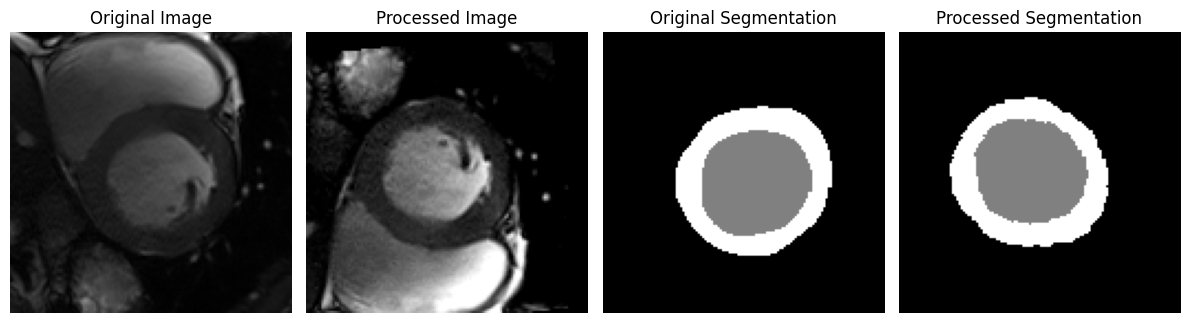

In [7]:
# let's try our dataload to see how the data augmentation looks like

# if you see error "local variable 'image_loaded' referenced before assignment", that's because you fail the code and directly run again. 
# to solve, please restart the jupyter notebook and run again --> actually you can just ignore the error and keep running, it won't affect anything
dl = DataLoader(generator_train, batch_size = 1, shuffle = False, pin_memory = True, num_workers = 0)# cpu_count())
for batch_idx, batch_data in enumerate(dl):
    original_img = batch_data["original_image"]
    original_seg = batch_data["original_seg"]
    processed_img = batch_data["image"]
    processed_seg = batch_data["mask"]
    print('processed image shape:', processed_img.shape)
   
    # plot 4 images side by side --> you should see the data augmentation effects
    fig, axs = plt.subplots(1, 4, figsize=(12, 4))
    axs[0].imshow(original_img[0,0,:,:,0], cmap='gray')
    axs[1].imshow(processed_img[0,0,:,:,0], cmap='gray')
    axs[2].imshow(original_seg[0,0,:,:,0], cmap='gray')
    axs[3].imshow(processed_seg[0,0,:,:,0], cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].set_title('Processed Image')
    axs[2].set_title('Original Segmentation')
    axs[3].set_title('Processed Segmentation')
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    break
    

### step 4: load pre-trained SAM model (freeze SAM blocks)

In [7]:
# set model
model = build_model(args, device)

# set freezed and trainable keys
train_keys = []
freezed_keys = []
        
# load pretrained sam model vit_h
if args.model_type.startswith("sam"):
    if args.resume.endswith(".pth"):
        with open(args.resume, "rb") as f:
            state_dict = torch.load(f)
        try:
            model.load_state_dict(state_dict)
        except:
            if args.vit_type == "vit_h" or args.vit_type == "vit_l" or args.vit_type == "vit_b":
                new_state_dict = load_from(model, state_dict, args.img_size,  16, [7, 15, 23, 31])
               
            model.load_state_dict(new_state_dict)
        
        # freeze original SAM layers
        freeze_list = [ "norm1", "attn" , "mlp", "norm2"]  
                
        for n, value in model.named_parameters():
            if any(substring in n for substring in freeze_list):
                freezed_keys.append(n)
                value.requires_grad = False
            else:
                train_keys.append(n)
                value.requires_grad = True

## Select optimization method
optimizer = MADGRAD(model.parameters(), lr=args.lr)
        
# Continue training model
if args.pretrained_model is not None:
    if os.path.exists(args.pretrained_model):
        print('loading pretrained model : ', args.pretrained_model)
        args.resume = args.pretrained_model
        finetune_checkpoint = torch.load(args.pretrained_model)
        model.load_state_dict(finetune_checkpoint["model"])
        optimizer.load_state_dict(finetune_checkpoint["optimizer"])
        torch.cuda.empty_cache()
else:
    print('new training\n')

Important! text prompt: False
Important! box prompt: False
new training



In [10]:
# training loader
data_loader_train = DataLoader(generator_train, batch_size = 1, shuffle = False, pin_memory = True, num_workers = 0)# cpu_count())

training_log = []
model_save_folder = os.path.join(output_dir, 'models'); ff.make_folder([output_dir, model_save_folder])
log_save_folder = os.path.join(output_dir, 'logs'); ff.make_folder([log_save_folder])

for epoch in range(args.start_epoch,  args.total_training_epochs+1):
        print('training epoch:', epoch)

        if epoch % args.lr_update_every_N_epoch == 0:
            optimizer.param_groups[0]["lr"] = optimizer.param_groups[0]["lr"] * args.lr_decay_gamma
        # print('learning rate now:', optimizer.param_groups[0]["lr"])
        
        loss_scaler = NativeScaler()
            
        train_results = train_loop1(
                model = model,
                data_loader_train  = data_loader_train,
                optimizer = optimizer,
                epoch = epoch, 
                loss_scaler = loss_scaler,
                args = args,
                inputtype = cfg.data.input_type)   
              
        loss, lossCE, lossDICE = train_results
        print('in epoch: ', epoch, ' training average_loss: ', loss, ' average_lossCE: ', lossCE, ' average_lossDICE: ', lossDICE,)
    
        # on_epoch_end:
        generator_train.on_epoch_end()
    
        if  epoch % args.save_model_file_every_N_epoch == 0 or epoch  == args.total_training_epochs:
            checkpoint_path = os.path.join(model_save_folder,  'model-%s.pth' % epoch)
            to_save = {
                        'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'epoch': epoch,
                        'scaler': loss_scaler.state_dict(),
                        'args': args,}
            torch.save(to_save, checkpoint_path)

        training_log.append([epoch, optimizer.param_groups[0]["lr"], loss, lossCE, lossDICE])
        df = pd.DataFrame(training_log, columns=['epoch', 'lr','training_loss', 'training_lossCE', 'training_lossDICE'])
        df.to_excel(os.path.join(log_save_folder, 'training_log.xlsx'), index=False)

training epoch: 1


100%|██████████| 1/1 [00:02<00:00,  2.39s/it]


in epoch:  1  training average_loss:  0.842536211013794  average_lossCE:  19.091644287109375  average_lossDICE:  0.842536211013794
training epoch: 2


100%|██████████| 1/1 [00:00<00:00, 13.18it/s]


in epoch:  2  training average_loss:  0.8224812150001526  average_lossCE:  31.012697219848633  average_lossDICE:  0.8224812150001526
training epoch: 3


...

in epoch:  4149  training average_loss:  0.08762848377227783  average_lossCE:  6.880716323852539  average_lossDICE:  0.08762848377227783


training epoch: 4150


100%|██████████| 1/1 [00:00<00:00,  9.22it/s]

in epoch:  4150  training average_loss:  0.089138925075531  average_lossCE:  7.068726539611816  average_lossDICE:  0.089138925075531


KeyboardInterrupt: 

In [9]:
import os
from tqdm import tqdm
import torch
import nibabel as nb
import numpy as np
from typing import Iterable
# from tensorboardX import SummaryWriter
import logging
from einops import rearrange
import utils.misc as misc
import utils.lr_sched as lr_sched
import torch.nn.functional as F
import SAM_echo_xjtlu.functions_collection as ff
def train_loop1(model: torch.nn.Module,
               data_loader_train: Iterable,
               optimizer: torch.optim.Optimizer,
               epoch: int, 
               loss_scaler,
               args=None,
               inputtype = None):
    
    # # make some settings
    # metric_logger = misc.MetricLogger(delimiter="  ")
    # metric_logger.add_meter('lr', misc.SmoothedValue(window_size=1, fmt='{value:.6f}'))
    # header = 'Epoch: [{}]'.format(epoch)
     
    accum_iter = args.accum_iter
    
    model.train(True)
    
    if args.turn_zero_seg_slice_into is not None:
        criterionBCE = torch.nn.CrossEntropyLoss(ignore_index=10)
        # print('in train loop we have turn_zero_seg_slice_into: ', args.turn_zero_seg_slice_into)
    else:
        criterionBCE = torch.nn.CrossEntropyLoss()

    # start to train
    average_loss = []; average_lossCE = []; average_lossDICE = []

        
    for data_iter_step, batch in enumerate(tqdm(data_loader_train)):
        with torch.cuda.amp.autocast():
            if (data_iter_step + 1) % accum_iter == 0 or data_iter_step == len(data_loader_train) - 1:
                optimizer.zero_grad()

            batch["image"]= batch["image"].float().cuda()
            # print('batch image shape:', batch["image"].shape)
                
            output = model(batch, args.img_size)
            # print('output shape: ',output["masks"].shape)

            mask = batch["mask"]
            mask = rearrange(mask, 'b c h w d -> (b d) c h w ').to("cuda")
            # print('mask shape: ', mask.shape, ' unique mask values: ', torch.unique(mask))
                   
            lossCE = criterionBCE(output["masks"], torch.clone(mask).squeeze(1).long()) 
            lossDICE = ff.customized_dice_loss(output["masks"], torch.clone(mask).squeeze(1).long(), num_classes = args.num_classes)#, exclude_index = args.turn_zero_seg_slice_into)
            # print('lossCE:', lossCE.item(), ' lossDICE:', lossDICE.item())

            #### total loss: weighted loss
            loss = args.loss_weights[0] * lossCE + args.loss_weights[1] * lossDICE
                   
            if torch.isnan(loss):
                continue

            subset_params = [p for p in model.parameters()]
            # print('number of subset params:', len(subset_params))
                
            # I'll not use the complicated loss scaler here
            # loss_scaler(loss, optimizer, parameters=subset_params,update_grad = True)#, update_grad=(data_iter_step + 1) % accum_iter == 0)  
            # backward using the easiest way
            if (data_iter_step + 1) % accum_iter == 0 or data_iter_step == len(data_loader_train) - 1:
                loss.backward()
                optimizer.step()
          
            torch.cuda.synchronize()
            # metric_logger.update(loss1=loss.item())
            # lr = optimizer.param_groups[0]["lr"]
            # metric_logger.update(lr=lr)

            # metric_logger.synchronize_between_processes()
            # print("Averaged stats:", metric_logger)
        
            average_loss.append(loss.item()); average_lossCE.append(lossCE.item()); average_lossDICE.append(lossDICE.item())
            

    average_loss_mean = sum(average_loss)/len(average_loss);average_lossCE_mean = sum(average_lossCE)/len(average_lossCE);average_lossDICE_mean = sum(average_lossDICE)/len(average_lossDICE)
    
    
    return [average_loss_mean, average_lossCE_mean, average_lossDICE_mean]
